# **KNN — Regresión**

Objetivo: predecir el **`promedio_final`** del estudiante, definido como:

$$\text{promedio\_final} = \frac{\text{grade}_{sem1} + \text{grade}_{sem2}}{2}$$



## **Pipeline de Regresión**

In [51]:
mutual_info_reg_seeded = partial(mutual_info_regression, random_state=SEED)

def make_reg_pipeline(k, top_n):
    """
    Hiperparámetros del grid:
        k     : vecinos KNN             — {3, 5, 7, 9, 11}
        top_n : features a seleccionar — {5, 8, 10, 15}
    """
    return Pipeline([
        ("prep",   clone(preprocessor)),
        ("select", SelectKBest(mutual_info_reg_seeded, k=top_n)),
        ("knn",    KNeighborsRegressor(n_neighbors=k, metric="euclidean")),
    ])

K_VALUES_REG    = [3, 5, 7, 9, 11]
TOPN_VALUES_REG = [5, 8, 10, 15]
N_SPLITS_REG    = 5

y_reg_trainval = np.concatenate([y_reg_train, y_reg_val])

### **Grid Search Manual con Validación Cruzada**

Métrica guía: **RMSE** (menor es mejor).

Se usa RMSE en lugar de MAE porque penaliza más los errores grandes — un modelo
que predice notas muy alejadas de la realidad es más dañino que uno con errores
pequeños sistemáticos. Además es coherente con el uso de mínimos cuadrados implícito
en KNN regresión (promedio de vecinos).

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

Se usa **KFold** en lugar de StratifiedKFold porque el target es continuo.


In [52]:
kf = KFold(n_splits=N_SPLITS_REG, shuffle=True, random_state=SEED)

cv_results_reg = []
total_combos   = len(K_VALUES_REG) * len(TOPN_VALUES_REG)

print(f"Grid Search Regresión: {total_combos} combinaciones × {N_SPLITS_REG} folds"
      f" = {total_combos * N_SPLITS_REG} fits\n")
print(f"{'top_n':>6}  {'k':>4}  "
      + "  ".join([f"RMSE f{i+1}" for i in range(N_SPLITS_REG)])
      + "     Media      Std")
print("─" * 88)

for top_n in TOPN_VALUES_REG:
    for k in K_VALUES_REG:
        fold_rmses = []
        for train_idx, val_idx in kf.split(X_trainval_raw):
            pipe = make_reg_pipeline(k, top_n)
            pipe.fit(X_trainval_raw.iloc[train_idx], y_reg_trainval[train_idx])
            y_pred_fold = pipe.predict(X_trainval_raw.iloc[val_idx])
            fold_rmses.append(np.sqrt(mean_squared_error(
                y_reg_trainval[val_idx], y_pred_fold)))

        cv_results_reg.append({
            "top_n"     : top_n,
            "k"         : k,
            "RMSE_media": np.mean(fold_rmses),
            "RMSE_std"  : np.std(fold_rmses),
        })
        folds_str = "  ".join([f"{s:.4f}" for s in fold_rmses])
        print(f"{top_n:>6}  {k:>4}  {folds_str}  "
              f"{np.mean(fold_rmses):>8.4f}  {np.std(fold_rmses):>7.4f}")
    print()

df_cv_reg    = pd.DataFrame(cv_results_reg)
best_row_reg = df_cv_reg.loc[df_cv_reg["RMSE_media"].idxmin()]
best_k_reg   = int(best_row_reg["k"])
best_top_n_reg = int(best_row_reg["top_n"])

print(f"\n→ Mejor combinación:")
print(f"   k*     = {best_k_reg}")
print(f"   top_n* = {best_top_n_reg}")
print(f"   RMSE   = {best_row_reg['RMSE_media']:.4f} ± {best_row_reg['RMSE_std']:.4f}")

Grid Search Regresión: 20 combinaciones × 5 folds = 100 fits

 top_n     k  RMSE f1  RMSE f2  RMSE f3  RMSE f4  RMSE f5     Media      Std
────────────────────────────────────────────────────────────────────────────────────────
     5     3  4.1725  3.8776  3.8657  3.8973  3.6754    3.8977   0.1590
     5     5  4.0808  3.7195  3.7954  3.7673  3.5423    3.7811   0.1738
     5     7  3.9595  3.6297  3.9119  3.7738  3.5750    3.7700   0.1509
     5     9  3.9009  3.5921  3.9931  3.7980  3.5694    3.7707   0.1671
     5    11  3.9130  3.5239  3.9963  3.7554  3.5219    3.7421   0.1950

     8     3  4.5299  3.8665  4.0005  3.8250  3.9595    4.0363   0.2547
     8     5  4.2168  3.7802  3.8225  3.7854  3.7535    3.8717   0.1739
     8     7  4.2084  3.6497  3.6774  3.8607  3.7196    3.8232   0.2058
     8     9  4.1299  3.5423  3.7670  3.8419  3.7278    3.8018   0.1915
     8    11  4.0817  3.5017  3.7329  3.8588  3.6761    3.7702   0.1935

    10     3  4.3810  3.9761  4.0219  3.9078  3.87

### **Visualización del Grid Search CV**

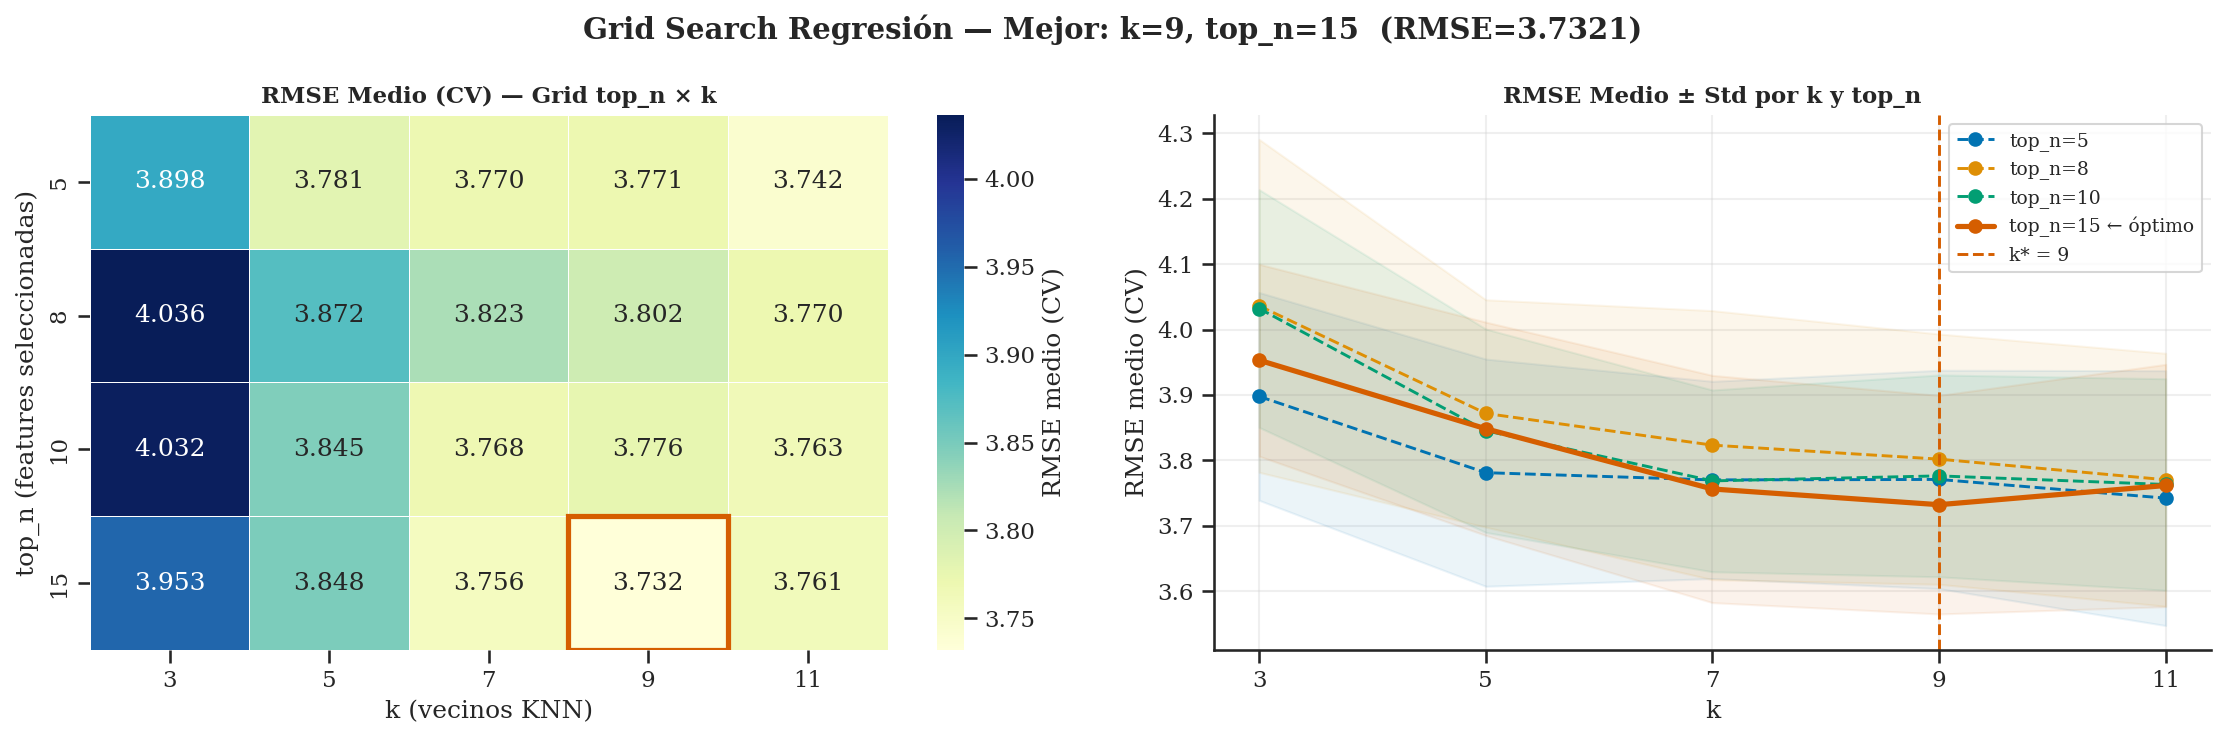

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivot_reg = df_cv_reg.pivot(index="top_n", columns="k", values="RMSE_media")
sns.heatmap(pivot_reg, annot=True, fmt=".3f", cmap=CMAP_SEQ,
            linewidths=0.4, ax=axes[0], cbar_kws={"label": "RMSE medio (CV)"})
best_row_idx = list(TOPN_VALUES_REG).index(best_top_n_reg)
best_col_idx = list(K_VALUES_REG).index(best_k_reg)
axes[0].add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                                  fill=False, edgecolor=C_ACCENT, lw=2.5))
axes[0].set_title("RMSE Medio (CV) — Grid top_n × k")
axes[0].set_xlabel("k (vecinos KNN)")
axes[0].set_ylabel("top_n (features seleccionadas)")

palette = sns.color_palette("colorblind", len(TOPN_VALUES_REG))
for idx, top_n in enumerate(TOPN_VALUES_REG):
    sub = df_cv_reg[df_cv_reg["top_n"] == top_n]
    axes[1].plot(sub["k"], sub["RMSE_media"],
                 marker="o",
                 lw=2.5 if top_n == best_top_n_reg else 1.4,
                 linestyle="-" if top_n == best_top_n_reg else "--",
                 color=palette[idx],
                 label=f"top_n={top_n}" + (" ← óptimo" if top_n==best_top_n_reg else ""))
    axes[1].fill_between(sub["k"],
                          sub["RMSE_media"] - sub["RMSE_std"],
                          sub["RMSE_media"] + sub["RMSE_std"],
                          alpha=0.08, color=palette[idx])

axes[1].axvline(best_k_reg, color=C_ACCENT, linestyle="--", lw=1.4,
                label=f"k* = {best_k_reg}")
axes[1].set(xlabel="k", ylabel="RMSE medio (CV)", xticks=K_VALUES_REG)
axes[1].set_title("RMSE Medio ± Std por k y top_n")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

sns.despine(ax=axes[1])
plt.suptitle(f"Grid Search Regresión — Mejor: k={best_k_reg}, top_n={best_top_n_reg}  "
             f"(RMSE={best_row_reg['RMSE_media']:.4f})",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## **Evaluación Final en Test**

Con `k*` y `top_n*` del grid search, reentrenamos sobre **todo X_trainval**
y evaluamos **una única vez** en test.

| Métrica | Qué mide | Escala |
|---|---|---|
| **MAE** | Error absoluto medio — robusto a outliers | Puntos (0–20) |
| **RMSE** | Penaliza errores grandes | Puntos (0–20) |
| **R²** | Proporción de varianza explicada por el modelo | 0–1 |

$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$

$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$

$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$


In [54]:
pipe_best_reg = make_reg_pipeline(best_k_reg, best_top_n_reg)
pipe_best_reg.fit(X_trainval_raw, y_reg_trainval)

y_pred_reg_test = pipe_best_reg.predict(X_test_raw)

mae  = mean_absolute_error(y_reg_test, y_pred_reg_test)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_test))
r2   = r2_score(y_reg_test, y_pred_reg_test)

print(f"Evaluación en Test — KNN Regresión (k={best_k_reg}, top_n={best_top_n_reg})\n")
print(f"  {'Métrica':<8} {'CV medio':>14}  {'Test':>10}")
print("  " + "─" * 36)
print(f"  {'RMSE':<8} {best_row_reg['RMSE_media']:>14.4f}  {rmse:>10.4f}")
print(f"  {'MAE':<8} {'—':>14}  {mae:>10.4f}")
print(f"  {'R²':<8} {'—':>14}  {r2:>10.4f}")

Evaluación en Test — KNN Regresión (k=9, top_n=15)

  Métrica        CV medio        Test
  ────────────────────────────────────
  RMSE             3.7321      3.7885
  MAE                   —      2.5571
  R²                    —      0.5004



### **Predicción vs Valor Real**

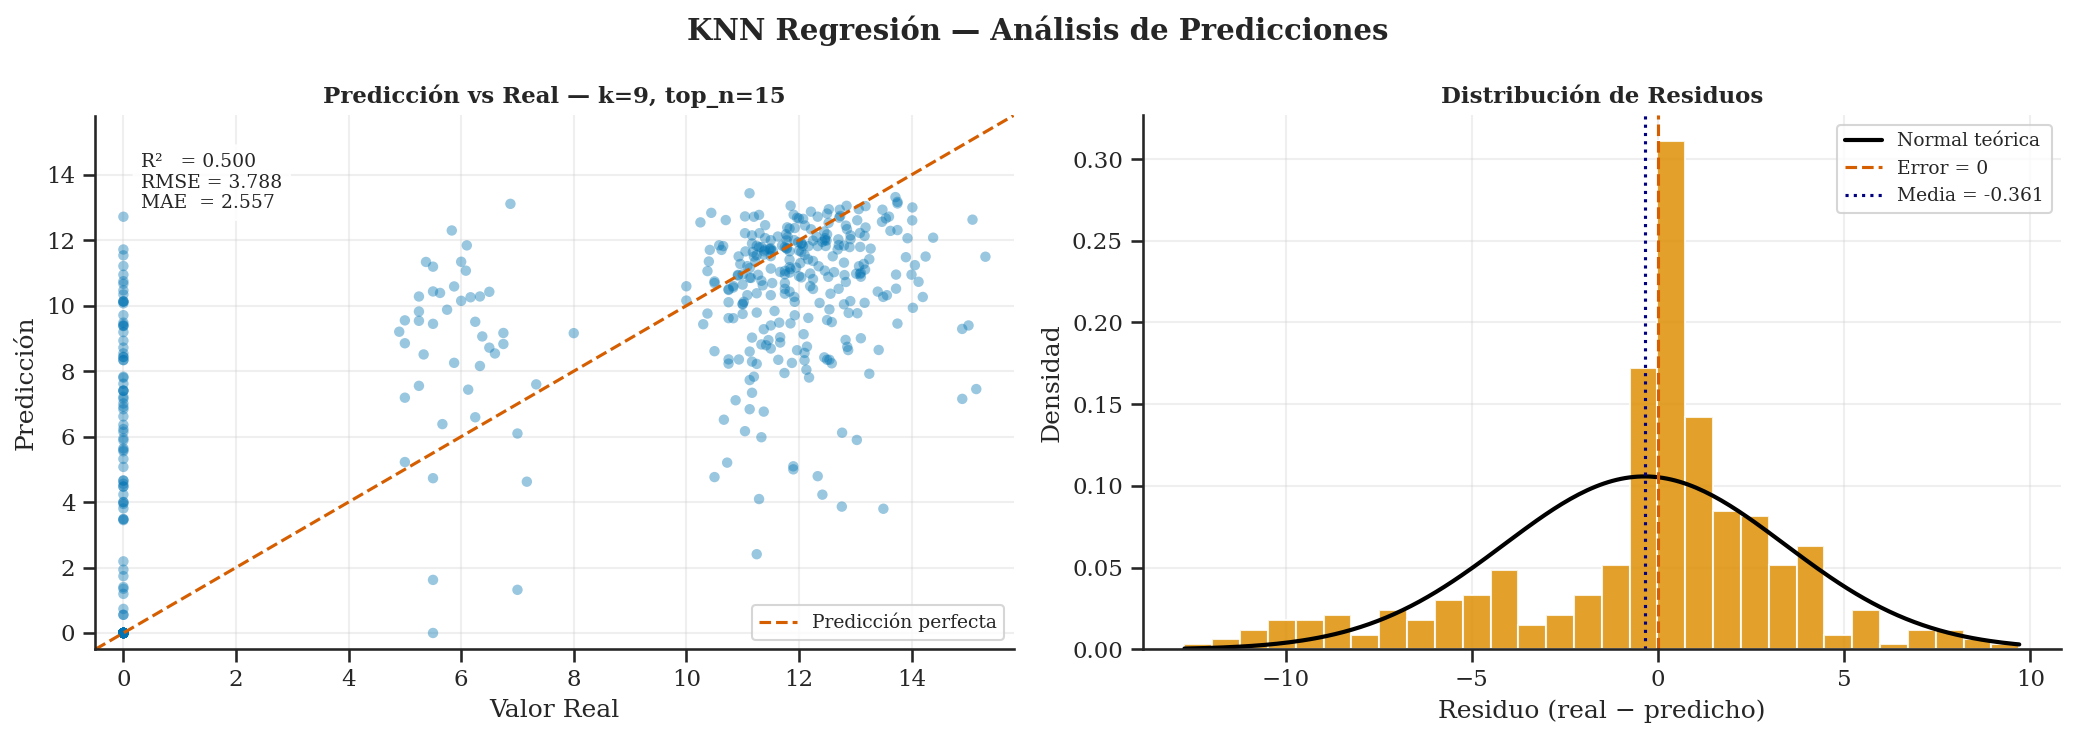

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_pred_reg_test,
                alpha=0.4, s=25, color=C_ENROLLED, edgecolors="none")
lims = [min(y_reg_test.min(), y_pred_reg_test.min()) - 0.5,
        max(y_reg_test.max(), y_pred_reg_test.max()) + 0.5]
axes[0].plot(lims, lims, color=C_ACCENT, lw=1.5, linestyle="--",
             label="Predicción perfecta")
axes[0].set(xlabel="Valor Real", ylabel="Predicción", xlim=lims, ylim=lims)
axes[0].set_title(f"Predicción vs Real — k={best_k_reg}, top_n={best_top_n_reg}")
axes[0].text(0.05, 0.93,
             f"R²   = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE  = {mae:.3f}",
             transform=axes[0].transAxes, fontsize=9, verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85))
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

residuos = y_reg_test - y_pred_reg_test
axes[1].hist(residuos, bins=30, color=C_DROPOUT, edgecolor="white",
             alpha=0.85, density=True)
x_norm = np.linspace(residuos.min(), residuos.max(), 200)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
             color="black", lw=2, label="Normal teórica")
axes[1].axvline(0, color=C_ACCENT, linestyle="--", lw=1.5, label="Error = 0")
axes[1].axvline(residuos.mean(), color="navy", linestyle=":", lw=1.5,
                label=f"Media = {residuos.mean():.3f}")
axes[1].set(xlabel="Residuo (real − predicho)", ylabel="Densidad")
axes[1].set_title("Distribución de Residuos")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

sns.despine()
plt.suptitle("KNN Regresión — Análisis de Predicciones",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## **Impacto de `k` en el Error de Predicción**

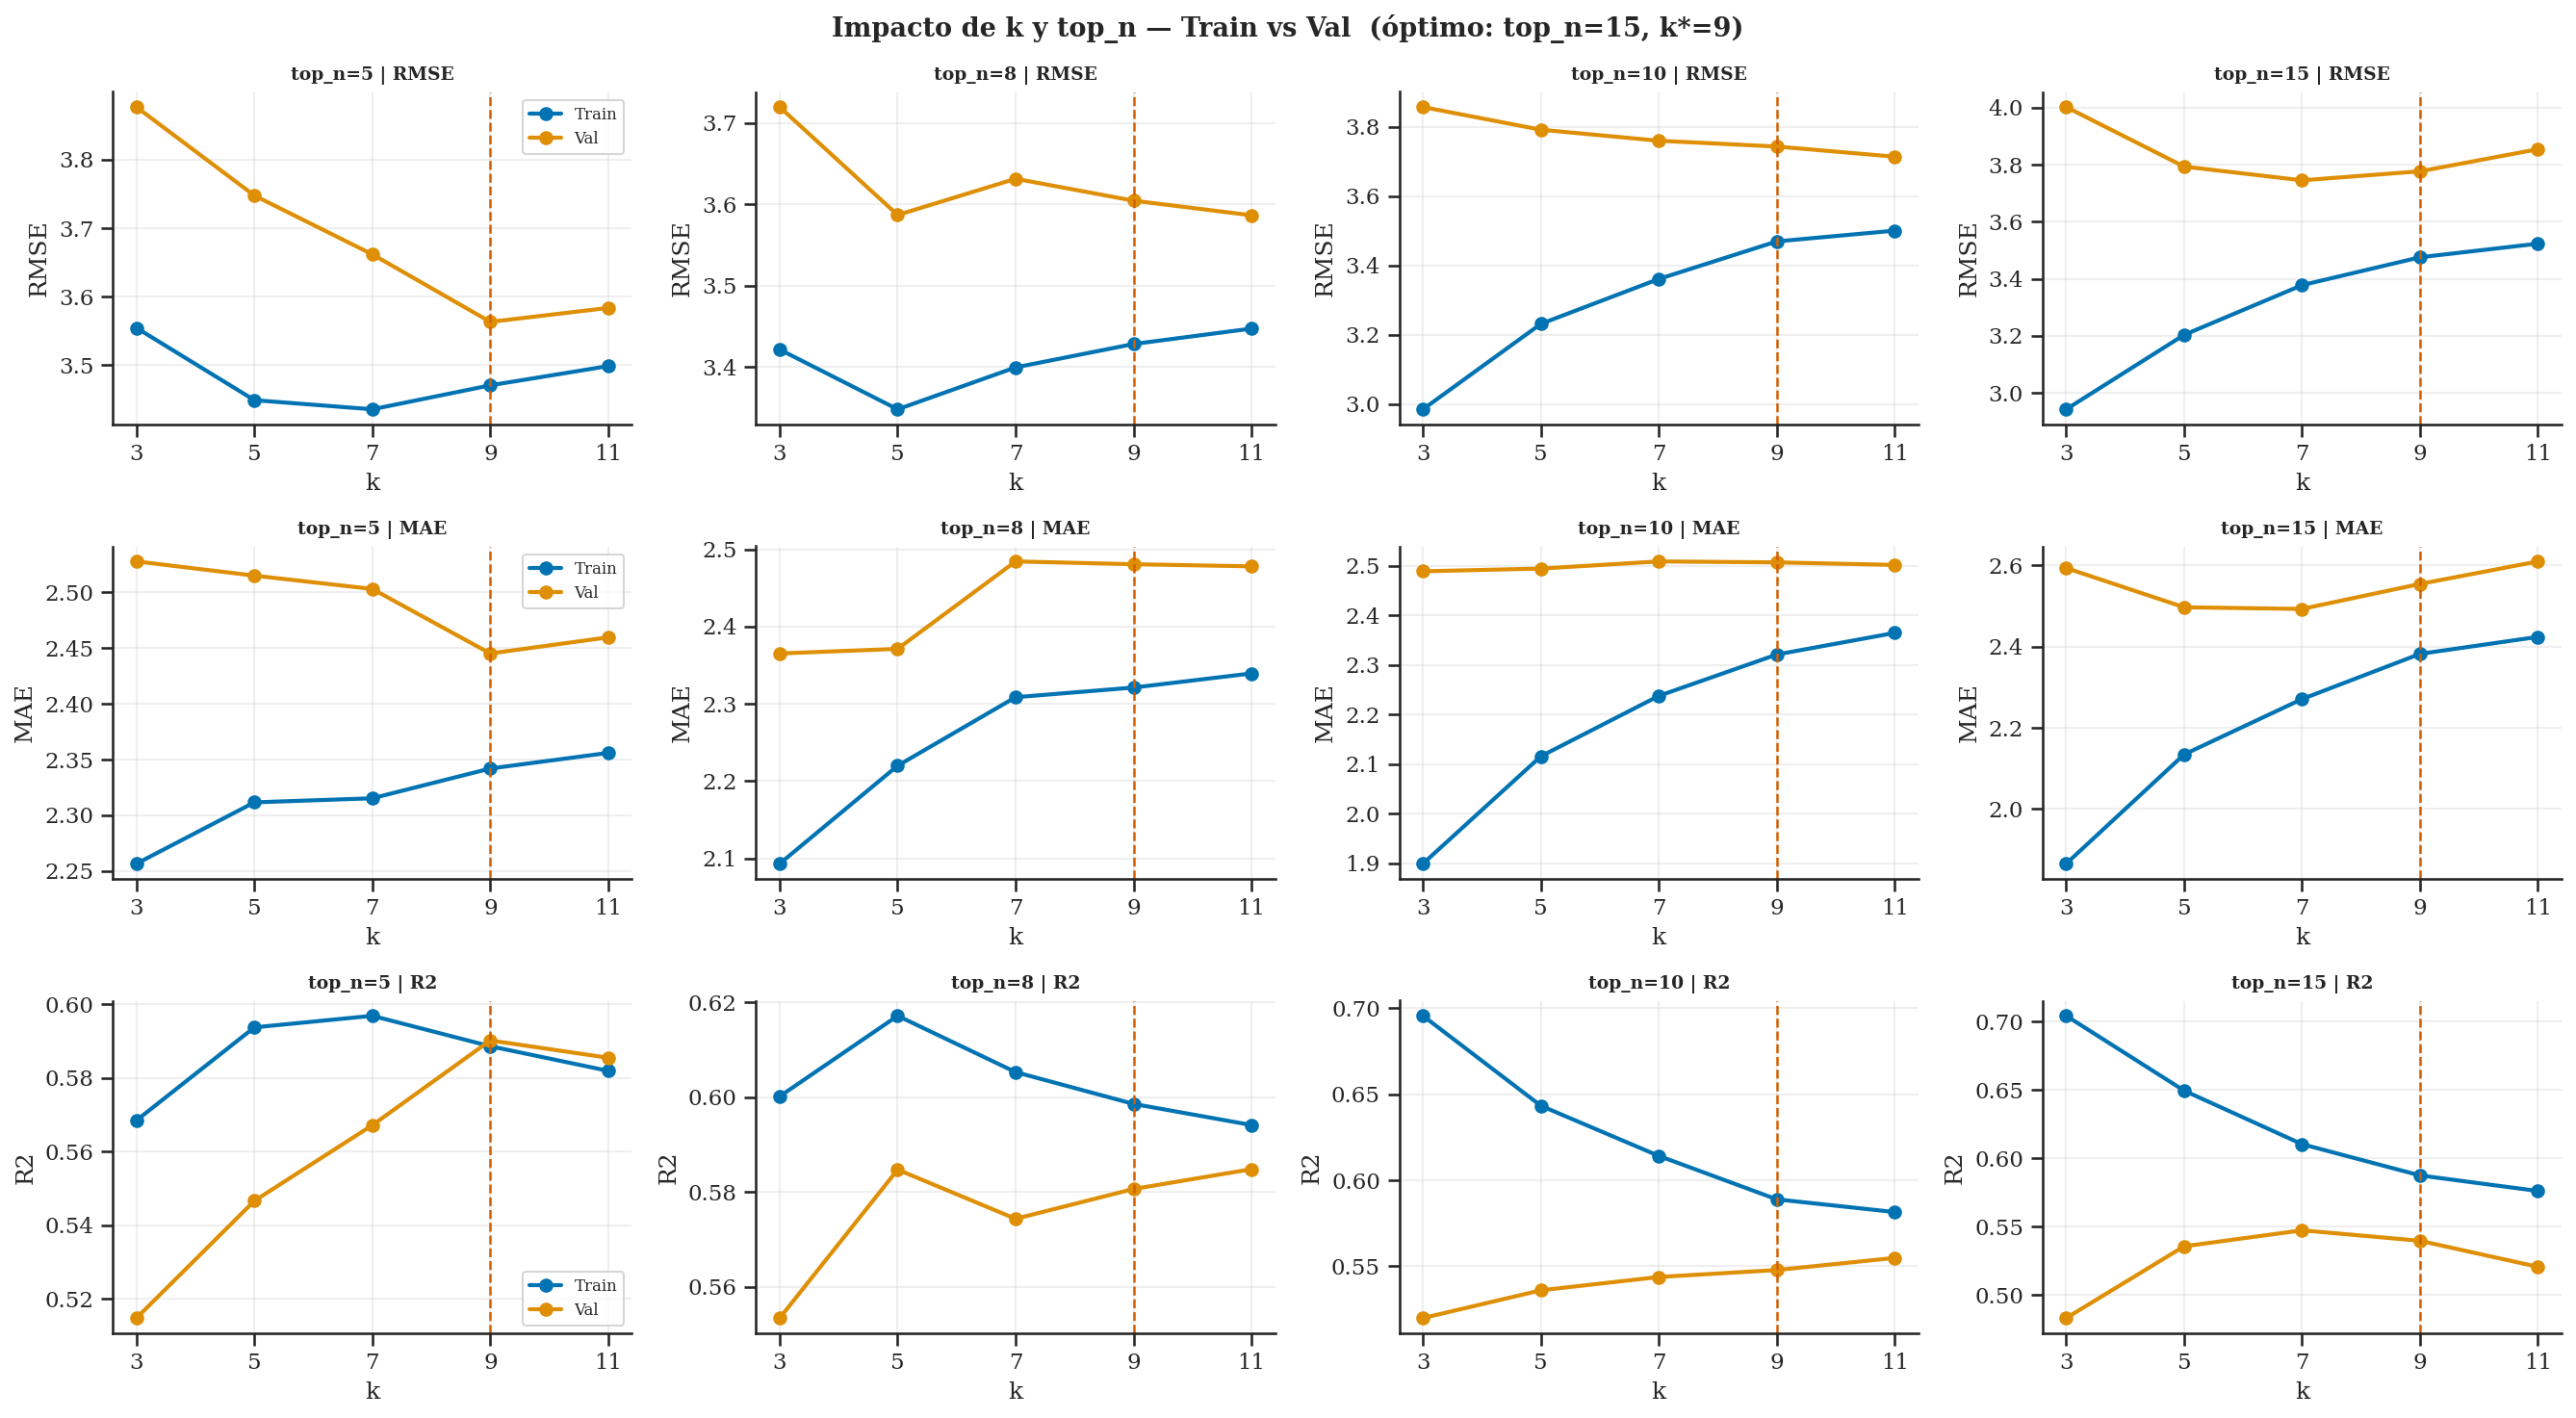


Resumen Val — top_n=15:


,RMSE,MAE,R2
k,,,
3,4.001900,2.593800,0.483000
5,3.793300,2.497100,0.535500
7,3.745200,2.493100,0.547200
9,3.776800,2.554700,0.539500
11,3.854300,2.610200,0.520500


In [56]:
records_reg = []
for top_n in TOPN_VALUES_REG:
    for k in K_VALUES_REG:
        p = make_reg_pipeline(k, top_n)
        p.fit(X_train_raw, y_reg_train)
        for split_name, X_s, y_s in [("Train", X_train_raw, y_reg_train),
                                       ("Val",   X_val_raw,   y_reg_val)]:
            y_p = p.predict(X_s)
            records_reg.append({
                "k"    : k,  "top_n": top_n,  "Split": split_name,
                "RMSE" : np.sqrt(mean_squared_error(y_s, y_p)),
                "MAE"  : mean_absolute_error(y_s, y_p),
                "R2"   : r2_score(y_s, y_p),
            })

df_k_reg    = pd.DataFrame(records_reg)
metrics_reg = ["RMSE", "MAE", "R2"]

fig, axes = plt.subplots(len(metrics_reg), len(TOPN_VALUES_REG), figsize=(18, 10))

for col, top_n in enumerate(TOPN_VALUES_REG):
    sub = df_k_reg[df_k_reg["top_n"] == top_n]
    for row, met in enumerate(metrics_reg):
        ax = axes[row][col]
        for split, grp in sub.groupby("Split"):
            ax.plot(grp["k"], grp[met], marker="o", lw=2,
                    label=split, color=COLORS_SPLIT[split])
        ax.axvline(best_k_reg, color=C_ACCENT, linestyle="--", lw=1.2)
        ax.set(xticks=K_VALUES_REG, xlabel="k", ylabel=met)
        ax.set_title(f"top_n={top_n} | {met}", fontsize=9)
        ax.grid(alpha=0.3)
        if col == 0:
            ax.legend(fontsize=8)

sns.despine()
plt.suptitle(f"Impacto de k y top_n — Train vs Val  "
             f"(óptimo: top_n={best_top_n_reg}, k*={best_k_reg})",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"\nResumen Val — top_n={best_top_n_reg}:")
display(_booktabs(
    df_k_reg[(df_k_reg["top_n"]==best_top_n_reg) & (df_k_reg["Split"]=="Val")]
    .set_index("k")[["RMSE","MAE","R2"]]
    .round(4)
    .style
    .highlight_min(subset=["RMSE","MAE"], props="font-weight: bold;")
    .highlight_max(subset=["R2"], props="font-weight: bold;")
))